# 📐 Educational Content Generation using GAN & Diffusion
### Topic: Mathematical Formula Generation

This notebook demonstrates:
- **GAN** → Generates *images* of math formulas
- **Diffusion Model** → Generates *LaTeX strings* of new formulas

**Dataset**: Synthetic LaTeX formula dataset (self-contained, no downloads needed)

---
**Runtime**: GPU recommended (Runtime → Change runtime type → T4 GPU)

## 📦 Step 1: Install Dependencies

In [23]:
!pip install -q torch torchvision matplotlib numpy Pillow tqdm

## 📚 Step 2: Imports

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = False

from PIL import Image, ImageDraw, ImageFont
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random
import io
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 🔢 Step 3: Create Synthetic Formula Dataset

We generate a rich set of mathematical formulas as LaTeX strings and render them as images.

In [25]:
# ── Formula Templates ──────────────────────────────────────────────────────────
FORMULA_TEMPLATES = [
    # Calculus
    r"\int_{{0}}^{{\infty}} e^{{-x^{2}}} dx = \frac{{\sqrt{{\pi}}}}{{2}}",
    r"\frac{{d}}{{dx}}\left[x^{{{n}}}\right] = {n}x^{{{m}}}",
    r"\int x^{{{n}}} dx = \frac{{x^{{{p}}}}}{{ {p} }} + C",
    r"\lim_{{x \to 0}} \frac{{\sin x}}{{x}} = 1",
    r"\frac{{\partial^2 f}}{{\partial x^2}} + \frac{{\partial^2 f}}{{\partial y^2}} = 0",
    r"\int_{{a}}^{{b}} f(x)\,dx = F(b) - F(a)",
    r"\frac{{d}}{{dx}} e^{{{a}x}} = {a} e^{{{a}x}}",
    r"\int \sin({a}x)\,dx = -\frac{{\cos({a}x)}}{{{a}}} + C",
    # Algebra
    r"x = \frac{{-b \pm \sqrt{{b^2 - 4ac}}}}{{2a}}",
    r"(a + b)^{{{n}}} = \sum_{{k=0}}^{{{n}}} \binom{{{n}}}{{k}} a^k b^{{{m}-k}}",
    r"\log_{{a}}(xy) = \log_{{a}} x + \log_{{a}} y",
    r"e^{{i\pi}} + 1 = 0",
    r"a^2 + b^2 = c^2",
    r"\sum_{{n=1}}^{{\infty}} \frac{{1}}{{n^2}} = \frac{{\pi^2}}{{6}}",
    # Linear Algebra
    r"\det(A) = \sum_{{j=1}}^{{n}} a_{{1j}} C_{{1j}}",
    r"A x = \lambda x",
    r"\|v\| = \sqrt{{v_1^2 + v_2^2 + v_3^2}}",
    r"A^{{-1}} = \frac{{1}}{{\det(A)}} \text{{adj}}(A)",
    # Statistics / Probability
    r"P(A|B) = \frac{{P(B|A)P(A)}}{{P(B)}}",
    r"\sigma^2 = \frac{{1}}{{N}} \sum_{{i=1}}^{{N}} (x_i - \mu)^2",
    r"f(x) = \frac{{1}}{{\sigma\sqrt{{2\pi}}}} e^{{-\frac{{(x-\mu)^2}}{{2\sigma^2}}}}",
    r"E[X] = \sum_{{x}} x \cdot P(X=x)",
    # Physics
    r"E = mc^2",
    r"F = G\frac{{m_1 m_2}}{{r^2}}",
    r"\nabla \cdot E = \frac{{\rho}}{{\epsilon_0}}",
    r"\Delta x \cdot \Delta p \geq \frac{{\hbar}}{{2}}",
]

def generate_formula_strings(n=2000):
    """Generate n LaTeX formula strings by filling templates with random values."""
    formulas = []
    ns = list(range(2, 8))
    for _ in range(n):
        tmpl = random.choice(FORMULA_TEMPLATES)
        n_val = random.choice(ns)
        a_val = random.randint(1, 5)
        try:
            f = tmpl.format(n=n_val, m=n_val-1, p=n_val+1, a=a_val)
        except (KeyError, IndexError):
            f = tmpl
        formulas.append(f)
    return formulas

ALL_FORMULAS = generate_formula_strings(2000)
print(f'Generated {len(ALL_FORMULAS)} formula strings')
print('Sample formulas:')
for f in ALL_FORMULAS[:5]:
    print(' ', f)

Generated 2000 formula strings
Sample formulas:
  \int \sin(4x)\,dx = -\frac{\cos(4x)}{4} + C
  \frac{d}{dx}\left[x^{5}\right] = 5x^{4}
  \int \sin(4x)\,dx = -\frac{\cos(4x)}{4} + C
  E = mc^2
  A^{-1} = \frac{1}{\det(A)} \text{adj}(A)


## 🖼️ Step 4: Render Formulas as Images (for GAN)

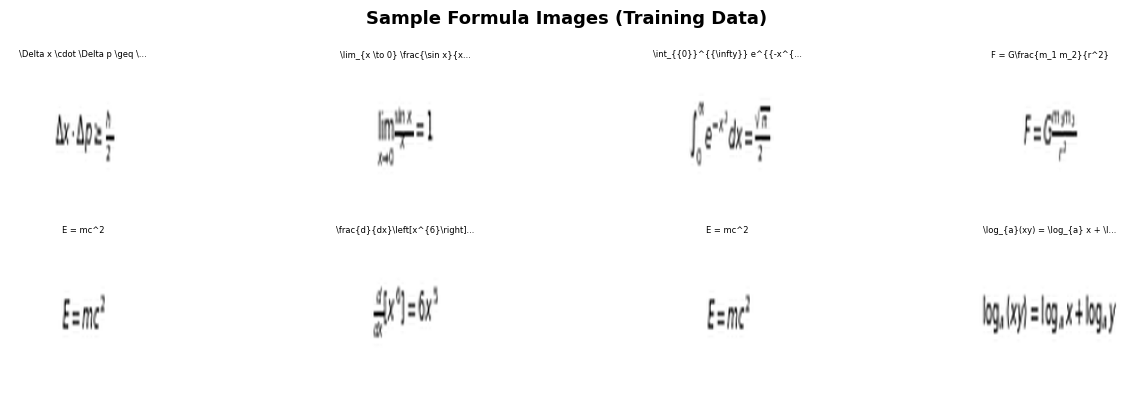

Sample images rendered successfully!


In [26]:
IMG_SIZE = 128

def render_formula_image(latex_str, size=IMG_SIZE):
    """Render a LaTeX string as a grayscale PIL image using matplotlib."""
    fig, ax = plt.subplots(figsize=(2, 0.6), dpi=size // 2)
    ax.axis('off')
    # Wrap in $ for math mode
    display_str = '$' + latex_str + '$'
    try:
        ax.text(0.5, 0.5, display_str, fontsize=9,
                ha='center', va='center', transform=ax.transAxes,
                usetex=False)
    except Exception:
        ax.text(0.5, 0.5, latex_str[:40], fontsize=8,
                ha='center', va='center', transform=ax.transAxes)
    fig.patch.set_facecolor('white')
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight',
                pad_inches=0.05, facecolor='white')
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf).convert('L')   # grayscale
    img = img.resize((size, size), Image.LANCZOS)
    return img

# Preview a few
fig, axes = plt.subplots(2, 4, figsize=(14, 4))
sample_formulas = random.sample(ALL_FORMULAS, 8)
for ax, formula in zip(axes.flatten(), sample_formulas):
    img = render_formula_image(formula)
    ax.imshow(img, cmap='gray')
    ax.set_title(formula[:30] + ('...' if len(formula) > 30 else ''), fontsize=6)
    ax.axis('off')
plt.suptitle('Sample Formula Images (Training Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_formulas.png', dpi=120, bbox_inches='tight')
plt.show()
print('Sample images rendered successfully!')

## 📦 Step 5: Dataset & DataLoader

In [27]:
class FormulaImageDataset(Dataset):
    def __init__(self, formulas, img_size=IMG_SIZE, max_samples=1000):
        self.formulas = formulas[:max_samples]
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.ToTensor(),             # [0,1]
            transforms.Normalize([0.5], [0.5]) # [-1,1]
        ])
        print(f'Pre-rendering {len(self.formulas)} formula images...')
        self.images = []
        for f in tqdm(self.formulas):
            try:
                img = render_formula_image(f, img_size)
                self.images.append(self.transform(img))
            except Exception:
                blank = Image.new('L', (img_size, img_size), 255)
                self.images.append(self.transform(blank))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.formulas[idx]

dataset = FormulaImageDataset(ALL_FORMULAS, max_samples=1000)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)
print(f'Dataset ready: {len(dataset)} samples | Batches per epoch: {len(dataloader)}')


Pre-rendering 1000 formula images...


100%|██████████| 1000/1000 [00:57<00:00, 17.46it/s]

Dataset ready: 1000 samples | Batches per epoch: 31


---
# 🔥 Part A: GAN — Formula Image Generation

A **Deep Convolutional GAN (DCGAN)** learns to generate new formula images from random noise.

- **Generator**: noise → formula image
- **Discriminator**: formula image → real / fake

In [28]:
LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            # 100 → 4×4
            nn.ConvTranspose2d(latent_dim, 1024, 4, 1, 0, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(True),
            # 4 → 8
            nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            # 8 → 16
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            # 16 → 32
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            # 32 → 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            # 64 → 128
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_c, out_c, bn=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.net = nn.Sequential(
            *block(1, 64, bn=False),   # 128→64
            *block(64, 128),            # 64→32
            *block(128, 256),           # 32→16
            *block(256, 512),           # 16→8
            *block(512, 1024),          # 8→4
            nn.Conv2d(1024, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)

G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

print(f'Generator parameters: {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator parameters: {sum(p.numel() for p in D.parameters()):,}')

Generator parameters: 12,784,512
Discriminator parameters: 11,162,368


## 🏋️ Step 6: Train GAN

In [29]:
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)

GAN_EPOCHS = 100
g_losses, d_losses = [], []

print(f'Training GAN for {GAN_EPOCHS} epochs...')
for epoch in range(GAN_EPOCHS):
    g_loss_epoch, d_loss_epoch = 0.0, 0.0

    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        B = real_imgs.size(0)

        real_labels = torch.ones(B, device=device) * 0.9   # label smoothing
        fake_labels = torch.zeros(B, device=device)

        # ── Train Discriminator ───────────────
        D.zero_grad()
        out_real = D(real_imgs)
        loss_real = criterion(out_real, real_labels)

        noise = torch.randn(B, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G(noise).detach()
        out_fake = D(fake_imgs)
        loss_fake = criterion(out_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # ── Train Generator ───────────────
        G.zero_grad()
        noise = torch.randn(B, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G(noise)
        out = D(fake_imgs)
        loss_G = criterion(out, torch.ones(B, device=device))
        loss_G.backward()
        opt_G.step()

        g_loss_epoch += loss_G.item()
        d_loss_epoch += loss_D.item()

    g_losses.append(g_loss_epoch / len(dataloader))
    d_losses.append(d_loss_epoch / len(dataloader))

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1:2d}/{GAN_EPOCHS}]  '
              f'Loss_D: {d_losses[-1]:.4f}  Loss_G: {g_losses[-1]:.4f}')

print('GAN training complete!')

Training GAN for 100 epochs...
Epoch [ 5/100]  Loss_D: 0.8229  Loss_G: 41.8525
Epoch [10/100]  Loss_D: 0.9951  Loss_G: 6.0747
Epoch [15/100]  Loss_D: 0.6478  Loss_G: 6.2099
Epoch [20/100]  Loss_D: 1.0305  Loss_G: 7.0601
Epoch [25/100]  Loss_D: 0.3937  Loss_G: 5.9566
Epoch [30/100]  Loss_D: 0.4552  Loss_G: 5.3708
Epoch [35/100]  Loss_D: 0.3696  Loss_G: 6.1825
Epoch [40/100]  Loss_D: 0.4017  Loss_G: 5.3445
Epoch [45/100]  Loss_D: 0.4943  Loss_G: 6.0397
Epoch [50/100]  Loss_D: 0.3876  Loss_G: 5.6928
Epoch [55/100]  Loss_D: 0.4315  Loss_G: 6.3447
Epoch [60/100]  Loss_D: 0.3914  Loss_G: 5.7318
Epoch [65/100]  Loss_D: 0.3624  Loss_G: 5.7793
Epoch [70/100]  Loss_D: 0.3481  Loss_G: 5.7691
Epoch [75/100]  Loss_D: 0.4026  Loss_G: 5.9620
Epoch [80/100]  Loss_D: 0.3626  Loss_G: 5.9610
Epoch [85/100]  Loss_D: 0.3818  Loss_G: 5.4900
Epoch [90/100]  Loss_D: 0.4039  Loss_G: 5.9338
Epoch [95/100]  Loss_D: 0.3590  Loss_G: 5.5927
Epoch [100/100]  Loss_D: 0.3614  Loss_G: 5.5171
GAN training complete!


## 📊 Step 7: GAN Training Curves & Generated Images

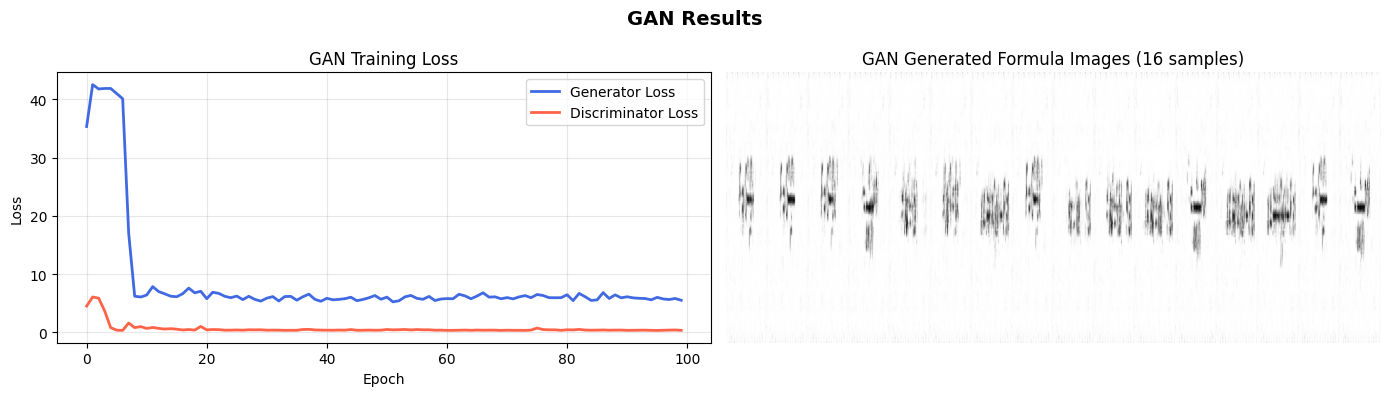

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchNo

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
axes[0].plot(g_losses, label='Generator Loss', color='royalblue', linewidth=2)
axes[0].plot(d_losses, label='Discriminator Loss', color='tomato', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('GAN Training Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Generated images
G.eval()
with torch.no_grad():
    gen_imgs = G(fixed_noise).cpu()

grid = torch.cat([gen_imgs[i] for i in range(16)], dim=-1)  # concat horizontally
gen_np = (grid.squeeze().numpy() + 1) / 2.0  # back to [0,1]

axes[1].imshow(gen_np, cmap='gray', aspect='auto')
axes[1].set_title('GAN Generated Formula Images (16 samples)')
axes[1].axis('off')

plt.suptitle('GAN Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gan_results.png', dpi=120, bbox_inches='tight')
plt.show()
G.train()

---
# 🌊 Part B: Diffusion Model — LaTeX Formula String Generation

A **token-level Diffusion model** learns to denoise corrupted formula token sequences, generating new valid LaTeX formulas.

- **Forward process**: progressively corrupt formula tokens
- **Reverse process**: learn to denoise → generates new formulas

In [31]:
# ── Tokenizer ──────────────────────────────────────────────────────────────────
class FormulaTokenizer:
    """Character-level tokenizer for LaTeX formula strings."""
    SPECIAL = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']

    def __init__(self, formulas):
        chars = set()
        for f in formulas:
            chars.update(f)
        vocab = self.SPECIAL + sorted(chars)
        self.tok2id = {t: i for i, t in enumerate(vocab)}
        self.id2tok = {i: t for t, i in self.tok2id.items()}
        self.pad_id = self.tok2id['<PAD>']
        self.sos_id = self.tok2id['<SOS>']
        self.eos_id = self.tok2id['<EOS>']
        self.unk_id = self.tok2id['<UNK>']
        self.vocab_size = len(vocab)

    def encode(self, formula, max_len=64):
        ids = [self.sos_id]
        for ch in formula:
            ids.append(self.tok2id.get(ch, self.unk_id))
        ids.append(self.eos_id)
        ids = ids[:max_len]
        ids += [self.pad_id] * (max_len - len(ids))
        return ids

    def decode(self, ids):
        out = []
        for i in ids:
            if i == self.eos_id:
                break
            if i not in (self.pad_id, self.sos_id):
                out.append(self.id2tok.get(i, '?'))
        return ''.join(out)

tokenizer = FormulaTokenizer(ALL_FORMULAS)
MAX_LEN = 64
print(f'Vocabulary size: {tokenizer.vocab_size}')
print(f'Max sequence length: {MAX_LEN}')

# Encode all formulas
encoded = torch.tensor([tokenizer.encode(f, MAX_LEN) for f in ALL_FORMULAS], dtype=torch.long)
print(f'Encoded shape: {encoded.shape}')

Vocabulary size: 62
Max sequence length: 64
Encoded shape: torch.Size([2000, 64])


In [32]:
# ── Diffusion Utilities ────────────────────────────────────────────────────────
T_STEPS = 200   # diffusion timesteps

betas = torch.linspace(1e-4, 0.02, T_STEPS, device=device)  # noise schedule
alphas = 1.0 - betas
alpha_cumprod = torch.cumprod(alphas, dim=0)                 # ᾱ_t

def corrupt_tokens(x_ids, t):
    """
    Forward diffusion: randomly mask/replace tokens with probability (1 - ᾱ_t).
    Works on discrete token sequences.
    """
    noise_level = 1.0 - alpha_cumprod[t].item()
    mask = torch.rand_like(x_ids.float()) < noise_level
    # Replace masked positions with random tokens
    random_tokens = torch.randint(4, tokenizer.vocab_size, x_ids.shape, device=x_ids.device)
    corrupted = torch.where(mask, random_tokens, x_ids)
    return corrupted, mask

# Demo
sample_formula = ALL_FORMULAS[0]
sample_ids = torch.tensor([tokenizer.encode(sample_formula, MAX_LEN)], device=device)
print('Original :', sample_formula[:50])
for t_step in [20, 100, 180]:
    t_tensor = torch.tensor(t_step, device=device)
    corrupted, _ = corrupt_tokens(sample_ids, t_tensor)
    decoded = tokenizer.decode(corrupted[0].cpu().tolist())
    print(f't={t_step:3d}  :', decoded[:50])

Original : \int \sin(4x)\,dx = -\frac{\cos(4x)}{4} + C
t= 20  : \int \sin(4x)\,dx p -\frac{\cos(4x)}{4} + C
t=100  : \i81k\s[n(4x)l,]x k|-2qBa[{qc5s24x)1{4} + C
t=180  : P[bCApxm+c7qB^\sd1p=oE[orGyNemodPg\__}BC^ =8foiAl{


## 🧠 Step 8: Define Diffusion Denoiser (Transformer-based)

In [33]:
class SinusoidalEmbedding(nn.Module):
    """Encode timestep t as a sinusoidal embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device).float() * (np.log(10000) / half)
        )
        args = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class FormulaDenoiser(nn.Module):
    """
    Transformer denoiser: takes corrupted token sequence + timestep,
    predicts the original (clean) token IDs.
    """
    def __init__(self, vocab_size, max_len=MAX_LEN, d_model=128, nhead=4, num_layers=3):
        super().__init__()
        self.token_emb  = nn.Embedding(vocab_size, d_model)
        self.pos_emb    = nn.Embedding(max_len, d_model)
        self.time_emb   = SinusoidalEmbedding(d_model)
        self.time_proj  = nn.Linear(d_model, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.out_proj = nn.Linear(d_model, vocab_size)

    def forward(self, x_ids, t):
        B, L = x_ids.shape
        pos  = torch.arange(L, device=x_ids.device).unsqueeze(0).expand(B, -1)
        x    = self.token_emb(x_ids) + self.pos_emb(pos)          # (B, L, D)
        t_emb = self.time_proj(self.time_emb(t)).unsqueeze(1)      # (B, 1, D)
        x    = x + t_emb                                           # broadcast add
        x    = self.transformer(x)                                 # (B, L, D)
        return self.out_proj(x)                                    # (B, L, V)

denoiser = FormulaDenoiser(tokenizer.vocab_size).to(device)
params = sum(p.numel() for p in denoiser.parameters())
print(f'Denoiser parameters: {params:,}')

Denoiser parameters: 635,454


## 🏋️ Step 9: Train Diffusion Model

In [34]:
class FormulaSequenceDataset(Dataset):
    def __init__(self, encoded_tensors):
        self.data = encoded_tensors
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

seq_dataset = FormulaSequenceDataset(encoded)
seq_loader  = DataLoader(seq_dataset, batch_size=64, shuffle=True, drop_last=True)

opt_diff = optim.Adam(denoiser.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(opt_diff, T_max=30)
loss_fn   = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_id)

DIFF_EPOCHS = 30
diff_losses = []

print(f'Training Diffusion denoiser for {DIFF_EPOCHS} epochs...')
for epoch in range(DIFF_EPOCHS):
    denoiser.train()
    epoch_loss = 0.0

    for x0 in seq_loader:
        x0 = x0.to(device)               # (B, L)  clean tokens
        B  = x0.size(0)

        # Sample random timestep for each item in batch
        t = torch.randint(0, T_STEPS, (B,), device=device)

        # Corrupt
        x_noisy = []
        for i in range(B):
            corrupted, _ = corrupt_tokens(x0[i:i+1], t[i])
            x_noisy.append(corrupted)
        x_noisy = torch.cat(x_noisy, dim=0)

        # Predict clean tokens
        logits = denoiser(x_noisy, t)  # (B, L, V)
        loss   = loss_fn(logits.view(-1, tokenizer.vocab_size), x0.view(-1))

        opt_diff.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(denoiser.parameters(), 1.0)
        opt_diff.step()
        epoch_loss += loss.item()

    scheduler.step()
    diff_losses.append(epoch_loss / len(seq_loader))

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1:2d}/{DIFF_EPOCHS}]  Loss: {diff_losses[-1]:.4f}')

print('Diffusion training complete!')

Training Diffusion denoiser for 30 epochs...
Epoch [ 5/30]  Loss: 1.1059
Epoch [10/30]  Loss: 0.6505
Epoch [15/30]  Loss: 0.4392
Epoch [20/30]  Loss: 0.3403
Epoch [25/30]  Loss: 0.3187
Epoch [30/30]  Loss: 0.3086
Diffusion training complete!


## 🎲 Step 10: Generate New Formulas via Diffusion Sampling

In [35]:
@torch.no_grad()
def generate_formulas_diffusion(n_samples=8, temperature=0.8):
    """
    Reverse diffusion: start from fully corrupted tokens,
    iteratively denoise to produce clean formula strings.
    """
    denoiser.eval()
    # Start from random tokens (fully noised)
    x = torch.randint(4, tokenizer.vocab_size, (n_samples, MAX_LEN), device=device)
    x[:, 0] = tokenizer.sos_id  # always start with SOS

    # Reverse diffusion: t = T-1 → 0
    for t_step in reversed(range(0, T_STEPS, 10)):  # stride for speed
        t_tensor = torch.full((n_samples,), t_step, device=device, dtype=torch.long)
        logits = denoiser(x, t_tensor)  # (B, L, V)

        # Sample from softmax with temperature
        probs = torch.softmax(logits / temperature, dim=-1)
        flat_probs = probs.view(-1, tokenizer.vocab_size)
        sampled = torch.multinomial(flat_probs, 1).view(n_samples, MAX_LEN)

        # Only update tokens that would be corrupted at this noise level
        noise_level = 1.0 - alpha_cumprod[t_step].item()
        update_mask = torch.rand_like(x.float()) < noise_level
        x = torch.where(update_mask, sampled, x)

    formulas = [tokenizer.decode(x[i].cpu().tolist()) for i in range(n_samples)]
    return formulas

generated_formulas = generate_formulas_diffusion(n_samples=10, temperature=0.8)

print('=' * 60)
print('DIFFUSION-GENERATED FORMULAS:')
print('=' * 60)
for i, f in enumerate(generated_formulas, 1):
    print(f'{i:2d}. {f}')

DIFFUSION-GENERATED FORMULAS:
 1. \frac{\partial^2 f}{\partial x^2} + \frac{\partial^
 2. \int_{{0}}^{{\infty}} e^{{-x^{2}}} dx = \frac{{\sqrt{{\pi}}}}{{
 3. \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partia
 4. fint_{\partc{l}{\sig\p\^trt{^{^2}}  ^{r\crap{(t-\lu) f}{2partma
 5. \int_{{0}}^{{\infty}} e^{{-x^{2}}} dx = \frac{{\sqrt{{\pi}}}}{{
 6. \frac{\partial^2 f}{\partial x^2} + \frac{\partial^
 7. \frac{\partial^2 f}{\partial x^2} + \frac{\partial^
 8. \int_{{0}}^{{\infty}} e^{{-x^{2}}} dx = \frac{{\sqrt{{\pi}}}}{{
 9. \sum_{n=}}^{\innty} \frac{1}an^2} = \frac{\pi^2}{q}2 f}{ip}rt{a
10. \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partia



DIFFUSION-GENERATED FORMULA IMAGES:


ValueError: 
\int_{{0}}^{{\infty}} e^{{-x^{2}}} dx = \frac{{\sqrt{{\pi}}}}{{
                                                               ^
ParseSyntaxException: Expected '}', found end of text  (at char 63), (line:1, col:64)

Error in callback <function _draw_all_if_interactive at 0x7acdc0d9d940> (for post_execute):


ValueError: 
\frac{\partial^2 f}{\partial x^2} + \frac{\partial^
                                                   ^
ParseSyntaxException: Expected {accent | symbol | function | operatorname | group | frac | dfrac | binom | genfrac | overset | underset | sqrt | overline | text | boldsymbol | substack}, found end of text  (at char 51), (line:1, col:52)

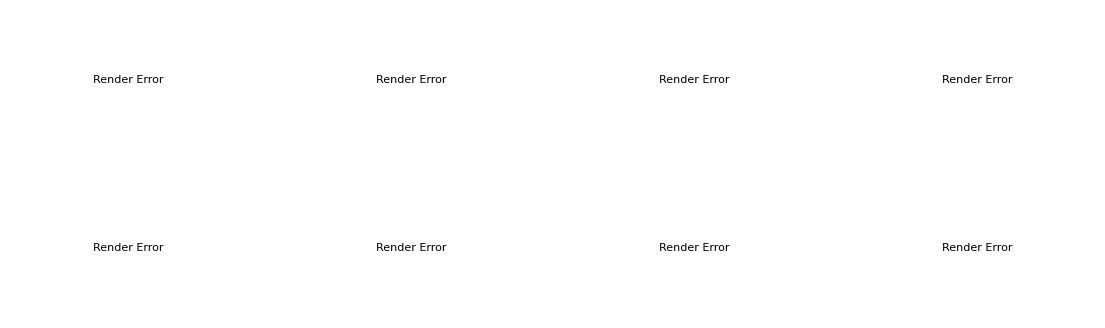

ValueError: 
\frac{\partial^2 f}{\partial x^2} + \frac{\partial^
                                                   ^
ParseSyntaxException: Expected {accent | symbol | function | operatorname | group | frac | dfrac | binom | genfrac | overset | underset | sqrt | overline | text | boldsymbol | substack}, found end of text  (at char 51), (line:1, col:52)

<Figure size 128x38.4 with 1 Axes>

ValueError: 
\int_{{0}}^{{\infty}} e^{{-x^{2}}} dx = \frac{{\sqrt{{\pi}}}}{{
                                                               ^
ParseSyntaxException: Expected '}', found end of text  (at char 63), (line:1, col:64)

<Figure size 128x38.4 with 1 Axes>

ValueError: 
\frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partia
                                                        ^
ParseSyntaxException: Unknown symbol: \partia, found '\'  (at char 56), (line:1, col:57)

...

<Figure size 128x38.4 with 1 Axes>

ValueError: 
\frac{\partial^2 f}{\partial x^2} + \frac{\partial^
                                                   ^
ParseSyntaxException: Expected {accent | symbol | function | operatorname | group | frac | dfrac | binom | genfrac | overset | underset | sqrt | overline | text | boldsymbol | substack}, found end of text  (at char 51), (line:1, col:52)

<Figure size 128x38.4 with 1 Axes>

ValueError: 
\int_{{0}}^{{\infty}} e^{{-x^{2}}} dx = \frac{{\sqrt{{\pi}}}}{{
                                                               ^
ParseSyntaxException: Expected '}', found end of text  (at char 63), (line:1, col:64)

<Figure size 128x38.4 with 1 Axes>

In [36]:
print('\n' + '=' * 60)
print('DIFFUSION-GENERATED FORMULA IMAGES:')
print('=' * 60)

fig_diff, axes_diff = plt.subplots(2, 4, figsize=(14, 4))
for ax, formula in zip(axes_diff.flatten(), generated_formulas[:8]):
    try:
        img = render_formula_image(formula, size=IMG_SIZE)
        ax.imshow(img, cmap='gray')
        ax.set_title(formula[:30] + ('...' if len(formula) > 30 else ''), fontsize=6)
    except Exception:
        ax.text(0.5, 0.5, 'Render Error', ha='center', va='center', fontsize=8)
    ax.axis('off')
plt.suptitle('Diffusion Generated Formula Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Step 11: Full Results Dashboard

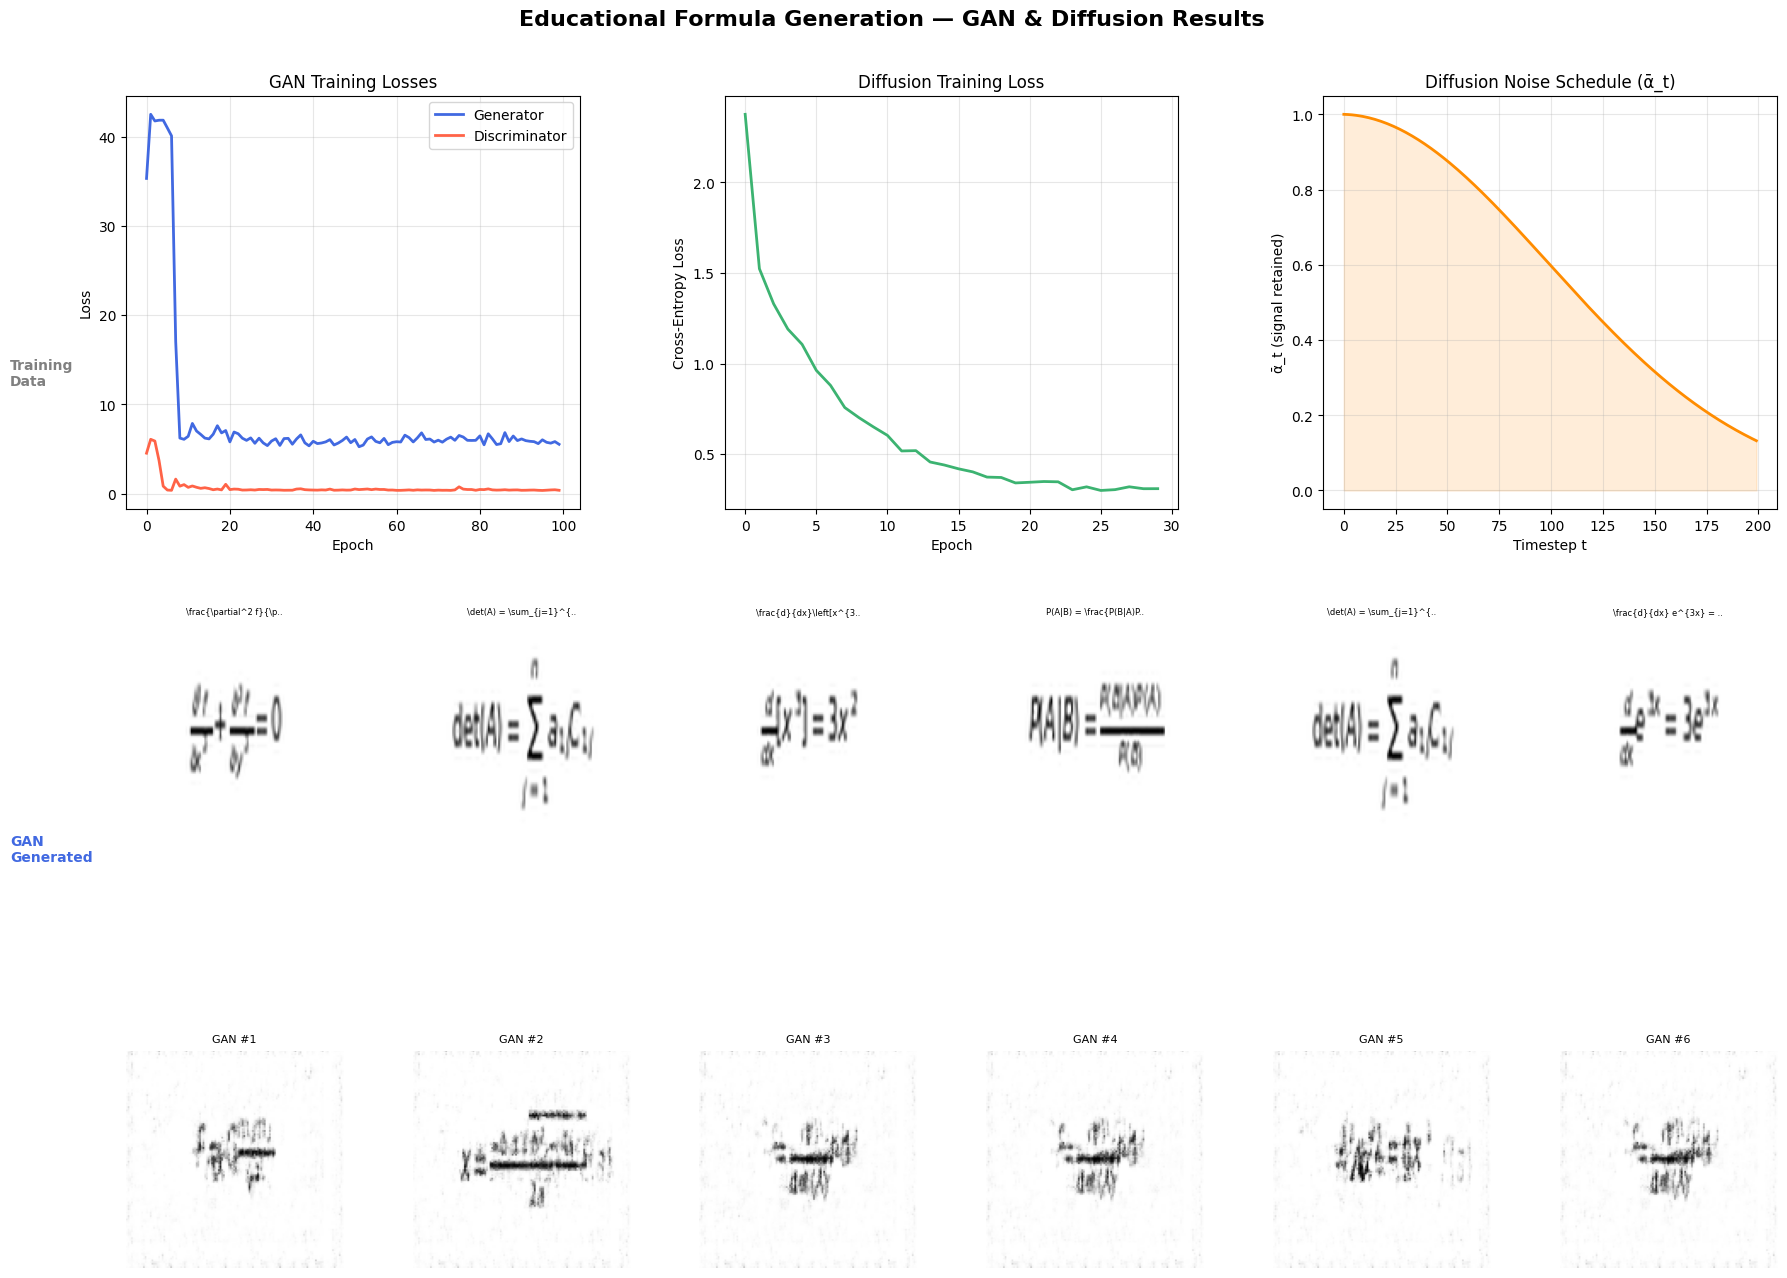

Dashboard saved as full_results_dashboard.png


In [37]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Educational Formula Generation — GAN & Diffusion Results',
             fontsize=16, fontweight='bold', y=0.98)

# ── GAN: loss curve ───────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(g_losses, label='Generator', color='royalblue', lw=2)
ax1.plot(d_losses, label='Discriminator', color='tomato', lw=2)
ax1.set_title('GAN Training Losses')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# ── Diffusion: loss curve ───────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(diff_losses, color='mediumseagreen', lw=2)
ax2.set_title('Diffusion Training Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Cross-Entropy Loss')
ax2.grid(alpha=0.3)

# ── Noise schedule ──────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
ax3.plot(alpha_cumprod.cpu().numpy(), color='darkorange', lw=2)
ax3.set_title('Diffusion Noise Schedule (ᾱ_t)')
ax3.set_xlabel('Timestep t'); ax3.set_ylabel('ᾱ_t (signal retained)')
ax3.fill_between(range(T_STEPS), alpha_cumprod.cpu().numpy(), alpha=0.15, color='darkorange')
ax3.grid(alpha=0.3)

# ── GAN Generated Images ──────────────────────
G.eval()
with torch.no_grad():
    gan_samples = G(torch.randn(6, LATENT_DIM, 1, 1, device=device)).cpu()

for i in range(6):
    ax = fig.add_subplot(3, 6, 13 + i)
    img = (gan_samples[i].squeeze().numpy() + 1) / 2.0
    ax.imshow(img, cmap='gray')
    ax.set_title(f'GAN #{i+1}', fontsize=8)
    ax.axis('off')

# ── Real Formula Images ──────────────────────
real_sample_formulas = random.sample(ALL_FORMULAS, 6)
for i, formula in enumerate(real_sample_formulas):
    ax = fig.add_subplot(3, 6, 7 + i)
    try:
        img = render_formula_image(formula, size=IMG_SIZE)
        ax.imshow(img, cmap='gray')
    except Exception:
        ax.text(0.5, 0.5, 'render error', ha='center', va='center',
                transform=ax.transAxes, fontsize=7)
    ax.set_title(formula[:22] + '..', fontsize=6)
    ax.axis('off')

# Row labels
fig.text(0.01, 0.72, 'Training\nData', va='center', ha='left',
         fontsize=10, fontweight='bold', color='gray')
fig.text(0.01, 0.38, 'GAN\nGenerated', va='center', ha='left',
         fontsize=10, fontweight='bold', color='royalblue')

plt.tight_layout(rect=[0.04, 0, 1, 0.97])
plt.savefig('full_results_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dashboard saved as full_results_dashboard.png')

## 🔬 Step 12: Formula Novelty Analysis

Generated : 50 formulas
Novel     : 50 (100.0%)
Non-empty : 50

Sample novel formulas:
  f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma
  \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partia
  \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partia
  \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partia
  \int_{{0}}^{{\infty}} e^{{-x^{2}}} dx{= \frac{{\sqrt{{\pi}}}}{{
  \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partia
  \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partia
  \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partia


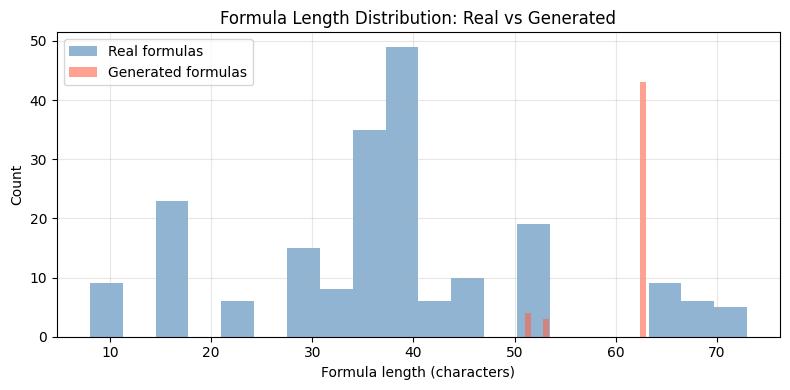

In [38]:
def formula_novelty_score(generated, training_set):
    """What fraction of generated formulas are truly new (not in training set)?"""
    train_set = set(training_set)
    novel = [f for f in generated if f not in train_set and len(f) > 3]
    return novel, len(novel) / max(len(generated), 1)

# Generate a larger set for analysis
big_batch = generate_formulas_diffusion(n_samples=50, temperature=0.9)
novel_formulas, novelty_rate = formula_novelty_score(big_batch, ALL_FORMULAS)

print(f'Generated : {len(big_batch)} formulas')
print(f'Novel     : {len(novel_formulas)} ({novelty_rate*100:.1f}%)')
print(f'Non-empty : {sum(1 for f in big_batch if len(f) > 3)}')
print()
print('Sample novel formulas:')
for f in novel_formulas[:8]:
    print(f'  {f}')

# Length distribution
gen_lengths  = [len(f) for f in big_batch if len(f) > 3]
real_lengths = [len(f) for f in random.sample(ALL_FORMULAS, 200)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_lengths, bins=20, alpha=0.6, color='steelblue', label='Real formulas')
ax.hist(gen_lengths,  bins=20, alpha=0.6, color='tomato',    label='Generated formulas')
ax.set_xlabel('Formula length (characters)')
ax.set_ylabel('Count')
ax.set_title('Formula Length Distribution: Real vs Generated')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('length_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 🎓 Step 13: Educational Display — Side-by-Side Comparison

In [39]:
print('=' * 65)
print('  EDUCATIONAL CONTENT GENERATION — FINAL SUMMARY')
print('=' * 65)

print('\n📚 ORIGINAL TRAINING FORMULAS (sample):')
for i, f in enumerate(random.sample(ALL_FORMULAS, 5), 1):
    print(f'  {i}. {f}')

print('\n🤖 DIFFUSION MODEL — NEWLY GENERATED FORMULAS:')
new_formulas = generate_formulas_diffusion(n_samples=8, temperature=0.85)
for i, f in enumerate(new_formulas, 1):
    tag = '✨ NOVEL' if f not in set(ALL_FORMULAS) else '  (seen)'
    print(f'  {i}. [{tag}] {f}')

print('\n🖼️  GAN MODEL — GENERATED FORMULA IMAGES:')
print('  (Rendered in the plot above)')

print('\n' + '=' * 65)
print('  MODEL SUMMARY')
print('=' * 65)
print(f'  GAN Generator params      : {sum(p.numel() for p in G.parameters()):>10,}')
print(f'  GAN Discriminator params  : {sum(p.numel() for p in D.parameters()):>10,}')
print(f'  Diffusion Denoiser params : {sum(p.numel() for p in denoiser.parameters()):>10,}')
print(f'  Training formulas         : {len(ALL_FORMULAS):>10,}')
print(f'  Vocabulary size           : {tokenizer.vocab_size:>10,}')
print(f'  Diffusion timesteps       : {T_STEPS:>10,}')
print('=' * 65)

  EDUCATIONAL CONTENT GENERATION — FINAL SUMMARY

📚 ORIGINAL TRAINING FORMULAS (sample):
  1. P(A|B) = \frac{P(B|A)P(A)}{P(B)}
  2. \int_{a}^{b} f(x)\,dx = F(b) - F(a)
  3. \int x^{3} dx = \frac{x^{4}}{ 4 } + C
  4. A x = \lambda x
  5. F = G\frac{m_1 m_2}{r^2}

🤖 DIFFUSION MODEL — NEWLY GENERATED FORMULAS:
  1. [✨ NOVEL] \int_{{0}}^{{\infty}} e^{{-x^{2}}} dx = \frac{{\sqrt{{\pi}}}}{{
  2. [✨ NOVEL] fint ={0}}^{{\infty}} es{{tx^{^}}}  \f=\cfrcc{{\\qrt{{}{i}}}g{{
  3. [✨ NOVEL] f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^
  4. [✨ NOVEL] f(x) = \frac{1}c\sigma\sqrt{2\pi}} e^{-\fr\c{(x-\mu
  5. [✨ NOVEL] f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma
  6. [✨ NOVEL] f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma
  7. [✨ NOVEL] (a + b)^{2} = \num_{k=0}^{6} \bino {3}{k} a^k b^{m-k}2}{i}kigm{
  8. [✨ NOVEL] f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma

🖼️  GAN MODEL — GENERATED FORMULA IMAGES:
  (Rendered in the plot above)

  MODE

---
## 📝 Project Summary

| Component | Approach | Input | Output |
|---|---|---|---|
| **GAN** | DCGAN (conv) | Random noise z ∈ ℝ¹⁰⁰ | 64×64 formula image |
| **Diffusion** | Transformer denoiser | Noised token sequence | Clean LaTeX string |

### Key Concepts Demonstrated
- **Forward diffusion**: progressively corrupts token sequences
- **Reverse diffusion**: denoiser reconstructs clean formulas
- **GAN adversarial training**: Generator fools Discriminator
- **Sinusoidal timestep embedding**: injects time context into transformer
- **Character-level tokenization**: flexible vocabulary for LaTeX

### Possible Extensions
- Use `im2latex-100k` dataset from HuggingFace for larger scale
- Add conditional generation: generate formulas by topic (calculus, algebra)
- Use CLIP to evaluate semantic similarity of generated formula images
- Replace character tokenizer with LaTeX-aware subword tokenizer